In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import joblib

In [25]:
df = pd.read_csv(
    "D:/forecasting/data/feature_engineered_data.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)

df.head()

(395604, 27)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Month,Quarter,Week,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_std_4,rolling_mean_8
0,1,1,2010-04-02,57258.43,False,62.27,2.719,0.0,0.0,0.0,...,4,2,13,26229.21,22136.64,21827.90,24924.50,22809.2850,2325.929203,27900.02750
1,1,1,2010-04-09,42960.91,False,65.86,2.770,0.0,0.0,0.0,...,4,2,14,57258.43,26229.21,21043.39,46039.49,31666.9175,17206.391261,31941.76875
2,1,1,2010-04-16,17596.96,False,66.32,2.808,0.0,0.0,0.0,...,4,2,15,42960.91,57258.43,22136.64,41595.55,37146.2975,16153.226819,31556.94625
3,1,1,2010-04-23,16145.35,False,64.84,2.795,0.0,0.0,0.0,...,4,2,16,17596.96,42960.91,26229.21,19403.54,36011.3775,17649.502493,28557.12250
4,1,1,2010-04-30,16555.11,False,67.41,2.780,0.0,0.0,0.0,...,4,2,17,16145.35,17596.96,57258.43,21827.90,33490.4125,20067.070906,28149.84875


In [26]:
feature_cols = [

    "Store",
    "Dept",

    "Type",
    "Size",

    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",

    "IsHoliday",

    "Year",
    "Month",
    "Quarter",
    "Week",

    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",

    "rolling_mean_4",
    "rolling_std_4",
    "rolling_mean_8"
]

target = "Weekly_Sales"

In [27]:
X = df[feature_cols]

y = df[target]

print(X.shape)
print(y.shape)

(395604, 25)
(395604,)


In [28]:
tscv = TimeSeriesSplit(
    n_splits=5
)

cv_results = []

In [29]:
xgb_cv = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_train_cv = X.iloc[train_idx]
    X_test_cv = X.iloc[test_idx]

    y_train_cv = y.iloc[train_idx]
    y_test_cv = y.iloc[test_idx]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_cv,
        y_train_cv
    )

    preds = model.predict(
        X_test_cv
    )

    xgb_cv.append(
        [
            fold,
            mean_absolute_error(
                y_test_cv,
                preds
            ),

            np.sqrt(
                mean_squared_error(
                    y_test_cv,
                    preds
                )
            ),

            r2_score(
                y_test_cv,
                preds
            )
        ]
    )

In [30]:
lgb_cv = []

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(X),
    start=1
):

    X_train_cv = X.iloc[train_idx]
    X_test_cv = X.iloc[test_idx]

    y_train_cv = y.iloc[train_idx]
    y_test_cv = y.iloc[test_idx]

    model = LGBMRegressor(

        n_estimators=300,

        max_depth=8,

        learning_rate=0.05,

        random_state=42
    )

    model.fit(
        X_train_cv,
        y_train_cv
    )

    preds = model.predict(
        X_test_cv
    )

    lgb_cv.append(
        [
            fold,

            mean_absolute_error(
                y_test_cv,
                preds
            ),

            np.sqrt(
                mean_squared_error(
                    y_test_cv,
                    preds
                )
            ),

            r2_score(
                y_test_cv,
                preds
            )
        ]
    )

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4040
[LightGBM] [Info] Number of data points in the train set: 65934, number of used features: 25
[LightGBM] [Info] Start training from score 17648.585358
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4162
[LightGBM] [Info] Number of data points in the train set: 131868, number of used features: 25
[LightGBM] [Info] Start training from score 18830.376091
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008005 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info]

In [31]:
xgb_cv_df = pd.DataFrame(
    xgb_cv,
    columns=[
        "Fold",
        "MAE",
        "RMSE",
        "R2"
    ]
)

lgb_cv_df = pd.DataFrame(
    lgb_cv,
    columns=[
        "Fold",
        "MAE",
        "RMSE",
        "R2"
    ]
)

cv_comparison = pd.DataFrame({

    "Model":[
        "XGBoost",
        "LightGBM"
    ],

    "Average MAE":[
        xgb_cv_df["MAE"].mean(),
        lgb_cv_df["MAE"].mean()
    ],

    "Average RMSE":[
        xgb_cv_df["RMSE"].mean(),
        lgb_cv_df["RMSE"].mean()
    ],

    "Average R2":[
        xgb_cv_df["R2"].mean(),
        lgb_cv_df["R2"].mean()
    ]
})

cv_comparison

,Model,Average MAE,Average RMSE,Average R2
0,XGBoost,1579.766251,4221.376909,0.962579
1,LightGBM,1642.855804,4020.338760,0.966079


In [32]:
split_date = "2012-02-01"

train_df = df[
    df["Date"] < split_date
]

test_df = df[
    df["Date"] >= split_date
]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df[target]
y_test = test_df[target]

In [33]:
naive_pred = X_test["lag_1"]

naive_mae = mean_absolute_error(
    y_test,
    naive_pred
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_pred
    )
)

naive_r2 = r2_score(
    y_test,
    naive_pred
)

In [34]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [35]:
lgbm = LGBMRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013579 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4278
[LightGBM] [Info] Number of data points in the train set: 280284, number of used features: 25
[LightGBM] [Info] Start training from score 16173.849289


,max_depth,8
,learning_rate,0.05
,n_estimators,300
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [36]:
xgb_preds = xgb.predict(
    X_test
)

lgb_preds = lgbm.predict(
    X_test
)

In [37]:
results = pd.DataFrame({

    "Model":[
        "Naive",
        "XGBoost",
        "LightGBM"
    ],

    "MAE":[

        naive_mae,

        mean_absolute_error(
            y_test,
            xgb_preds
        ),

        mean_absolute_error(
            y_test,
            lgb_preds
        )
    ],

    "RMSE":[

        naive_rmse,

        np.sqrt(
            mean_squared_error(
                y_test,
                xgb_preds
            )
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                lgb_preds
            )
        )
    ],

    "R2":[

        naive_r2,

        r2_score(
            y_test,
            xgb_preds
        ),

        r2_score(
            y_test,
            lgb_preds
        )
    ]
})

results

,Model,MAE,RMSE,R2
0,Naive,1679.605223,3816.494078,0.970395
1,XGBoost,1442.836210,3038.813889,0.981231
2,LightGBM,1462.264715,3135.378960,0.980019


In [38]:
importance = pd.DataFrame({

    "Feature": feature_cols,

    "Importance":
    xgb.feature_importances_

})

importance = (
    importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance.head(15)

,Feature,Importance
18,lag_1,0.462542
22,rolling_mean_4,0.318859
24,rolling_mean_8,0.077680
20,lag_4,0.028760
13,IsHoliday,0.016290
19,lag_2,0.011690
10,MarkDown3,0.010469
17,Week,0.010285
15,Month,0.010105
16,Quarter,0.007642


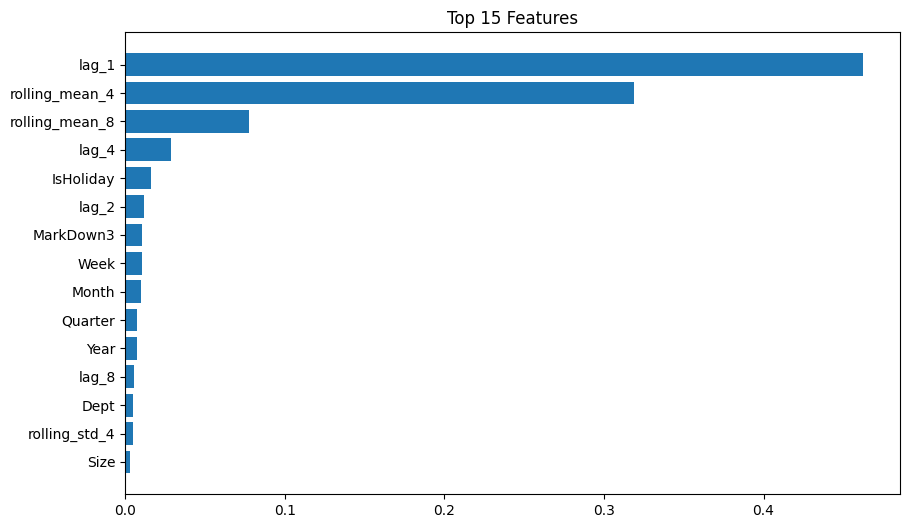

In [39]:
plt.figure(
    figsize=(10,6)
)

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 15 Features"
)

plt.show()

In [40]:
joblib.dump(
    xgb,
    "../models/xgb_forecasting_model.pkl"
)

['../models/xgb_forecasting_model.pkl']

In [41]:
predictions = test_df.copy()

predictions[
    "Predicted_Sales"
] = xgb_preds

predictions.to_csv(
    "../data/forecast_predictions.csv",
    index=False
)